# DOC-ANNs — Model Architecture (Figure 5)

This notebook reproduces **Figure 5** from Bonelli et al. (2022): a flowchart describing the DOC-ANNs system combining DOC-ANNa (coastal) and DOC-ANNb (open ocean) via Optical Water Class switching.

> Bonelli et al. (2022), *Remote Sensing of Environment*, 281, 113227. https://doi.org/10.1016/j.rse.2022.113227

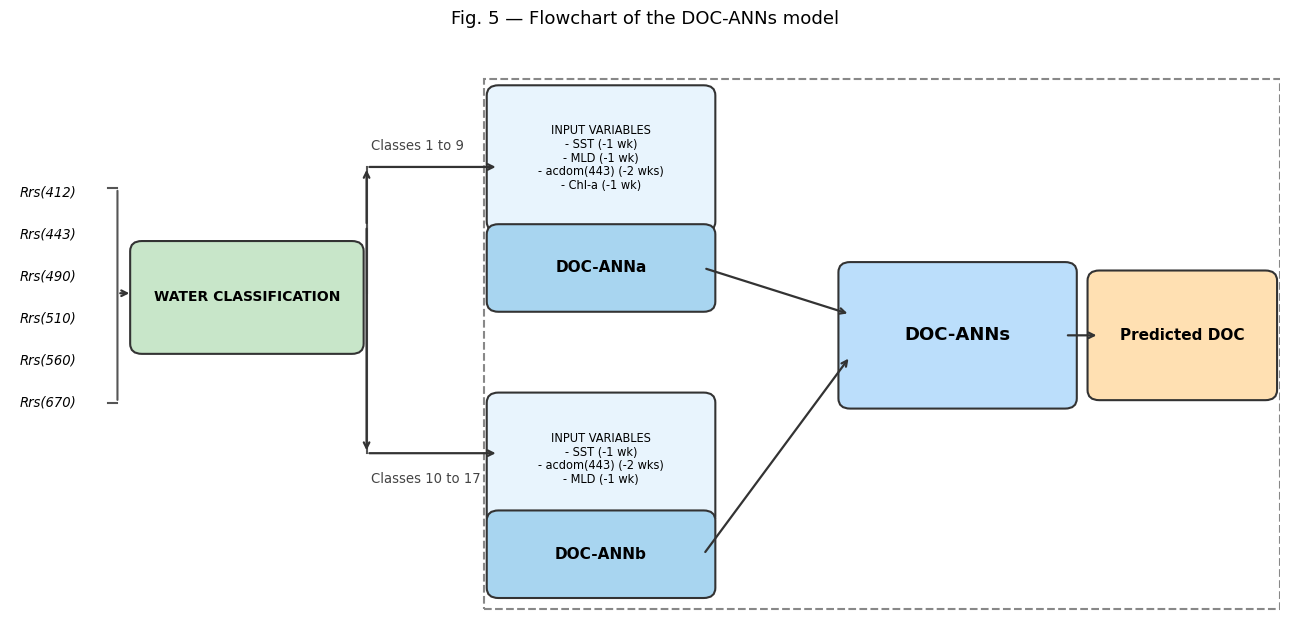

Saved.


In [47]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")

def box(ax, x, y, w, h, label, fontsize=10, color="#d0e8f5", bold=False):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.12",
                          linewidth=1.5, edgecolor="#333", facecolor=color, zorder=3)
    ax.add_patch(rect)
    fw = "bold" if bold else "normal"
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight=fw, zorder=4, multialignment="center")

def arr(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="#333", lw=1.6), zorder=5)

# ---- Rrs inputs (left column) ----
rrs_labels = ["Rrs(412)", "Rrs(443)", "Rrs(490)", "Rrs(510)", "Rrs(560)", "Rrs(670)"]
for i, v in enumerate(rrs_labels):
    ax.text(0.1, 5.2 - i*0.5, v, fontsize=9.5, va="center", ha="left", style="italic")

ax.annotate("", xy=(1.1, 2.7), xytext=(1.1, 5.25),
            arrowprops=dict(arrowstyle="-", color="#555", lw=1.5))
for yy in [2.7, 5.25]:
    ax.plot([1., 1.1], [yy, yy], color="#555", lw=1.5)

# ---- Water classification ----
box(ax, 1.35, 3.4, 2.15, 1.1, "WATER CLASSIFICATION", fontsize=10, color="#c8e6c9", bold=True)
arr(ax, 1.1, 4., 1.25, 4.)

# lines from classification to paths
ax.plot([3.65, 3.65], [2.1, 5.5], color="#555", lw=1.5)
arr(ax, 3.65, 5.5, 5.0, 5.5)
arr(ax, 3.65, 2.1, 5.0, 2.1)
ax.plot([3.65, 3.65], [4.0, 4.8], color="#555", lw=1.5)
arr(ax, 3.65, 4.8, 3.65, 5.5)
arr(ax, 3.65, 4.8, 3.65, 2.1)

# Labels
ax.text(3.7, 5.7, "Classes 1 to 9", fontsize=9.5, color="#444")
ax.text(3.7, 1.75, "Classes 10 to 17", fontsize=9.5, color="#444")

# ---- Input variable boxes ----
# ANNa inputs
box(ax, 5.0, 4.85, 2.1, 1.5, 
    "INPUT VARIABLES\n- SST (-1 wk)\n- MLD (-1 wk)\n- acdom(443) (-2 wks)\n- Chl-a (-1 wk)", 
    fontsize=8.2, color="#e8f4fd")

# ANNb inputs
box(ax, 5.0, 1.35, 2.1, 1.35, 
    "INPUT VARIABLES\n- SST (-1 wk)\n- acdom(443) (-2 wks)\n- MLD (-1 wk)", 
    fontsize=8.2, color="#e8f4fd")

# ---- ANN model boxes ----
box(ax, 5.0, 3.9, 2.1, 0.8, "DOC-ANNa", fontsize=11, color="#a8d5f0", bold=True)
box(ax, 5.0, 0.5, 2.1, 0.8, "DOC-ANNb", fontsize=11, color="#a8d5f0", bold=True)

# ---- DOC-ANNs (combined) ----
box(ax, 8.6, 2.75, 2.2, 1.5, "DOC-ANNs", fontsize=13, color="#bbdefb", bold=True)

# ---- Predicted DOC ----
box(ax, 11.15, 2.85, 1.7, 1.3, "Predicted DOC", fontsize=11, color="#ffe0b2", bold=True)

# ---- Arrows ----
arr(ax, 7.1, 4.3, 8.6, 3.75)
arr(ax, 7.1, 0.9, 8.6, 3.25)
arr(ax, 10.8, 3.5, 11.15, 3.5)

# Dashed box around DOC-ANNs system
from matplotlib.patches import Rectangle
rect2 = Rectangle((4.85, 0.25), 8.15, 6.3, linewidth=1.5, edgecolor="#888",
                   facecolor="none", linestyle="--", zorder=1)
ax.add_patch(rect2)

ax.set_title("Fig. 5 — Flowchart of the DOC-ANNs model", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../figures/Figure5_model_architecture.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved.")


## Model architecture details

### DOC-ANNa (Coastal waters, OWC classes 1-9)
- **Optimizer:** Adam
- **Architecture:** 1 hidden layer, 10 neurons
- **Activations:** ReLU (input->hidden), Linear (hidden->output)
- **Inputs:** SST (-1 wk), acdom(443) (-2 wks), MLD (-1 wk), Chl-a (-1 wk)

### DOC-ANNb (Open ocean, OWC classes 10-17)
- **Optimizer:** RMSprop
- **Architecture:** 2 hidden layers (10 + 3 nodes)
- **Activations:** Softmax (1st hidden), Exponential (2nd hidden)
- **Inputs:** SST (-1 wk), acdom(443) (-2 wks), MLD (-1 wk)

### The switching mechanism
Each pixel is first classified into one of 17 Optical Water Classes (OWC) using satellite Rrs(lambda). Classes 1-9 (optically complex coastal waters) use DOC-ANNa; classes 10-17 (clear open ocean) use DOC-ANNb.